In [1]:
from mpi4py import MPI
from petsc4py.PETSc import ScalarType  # type: ignore

import numpy as np
from matplotlib import pyplot as plt

import ufl
from dolfinx import fem, mesh, plot
from dolfinx.fem.petsc import LinearProblem

In [2]:
msh = mesh.create_rectangle(
    comm=MPI.COMM_WORLD,
    points=((0.0, 0.0), (2.0, 1.0)),
    n=(32, 1),
    cell_type=mesh.CellType.quadrilateral,
)
V = fem.functionspace(msh, ("Lagrange", 1))

facets = mesh.locate_entities_boundary(
    msh,
    dim=(msh.topology.dim - 1),
    marker=lambda x: np.isclose(x[0], 0.0) | np.isclose(x[0], 2.0),
)

dofs = fem.locate_dofs_topological(V=V, entity_dim=1, entities=facets)
bc = fem.dirichletbc(value=ScalarType(1), dofs=dofs, V=V)

In [3]:
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
x = ufl.SpatialCoordinate(msh)
f = 10 * ufl.exp(-((x[0] - 0.5) **2 + (x[1] - 0.5) ** 2) / 0.02)
g = ufl.sin(5 * x[0])
a = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = ufl.inner(f, v) * ufl.dx + ufl.inner(g, v) * ufl.ds

problem = LinearProblem(
    a,
    L,
    bcs=[bc],
    petsc_options_prefix="demo_poisson_",
    petsc_options={"ksp_type": "preonly", "pc_type": "lu", "ksp_error_if_not_converged": True},
)
uh = problem.solve()
assert isinstance(uh, fem.Function)

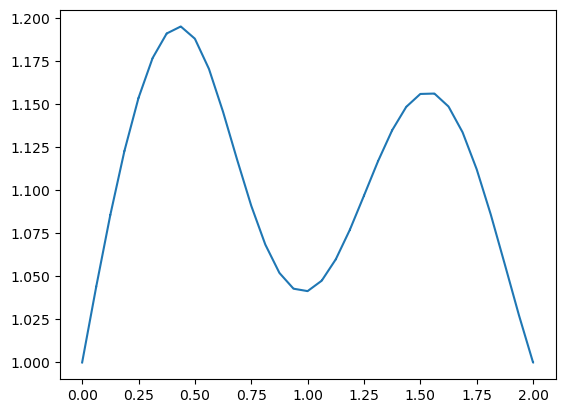

In [4]:
cells, types, x = plot.vtk_mesh(V)
plt.plot(x[:, 0], uh.x.array.real)
plt.show()

/tmp/ipykernel_9281/1421046159.py:12: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


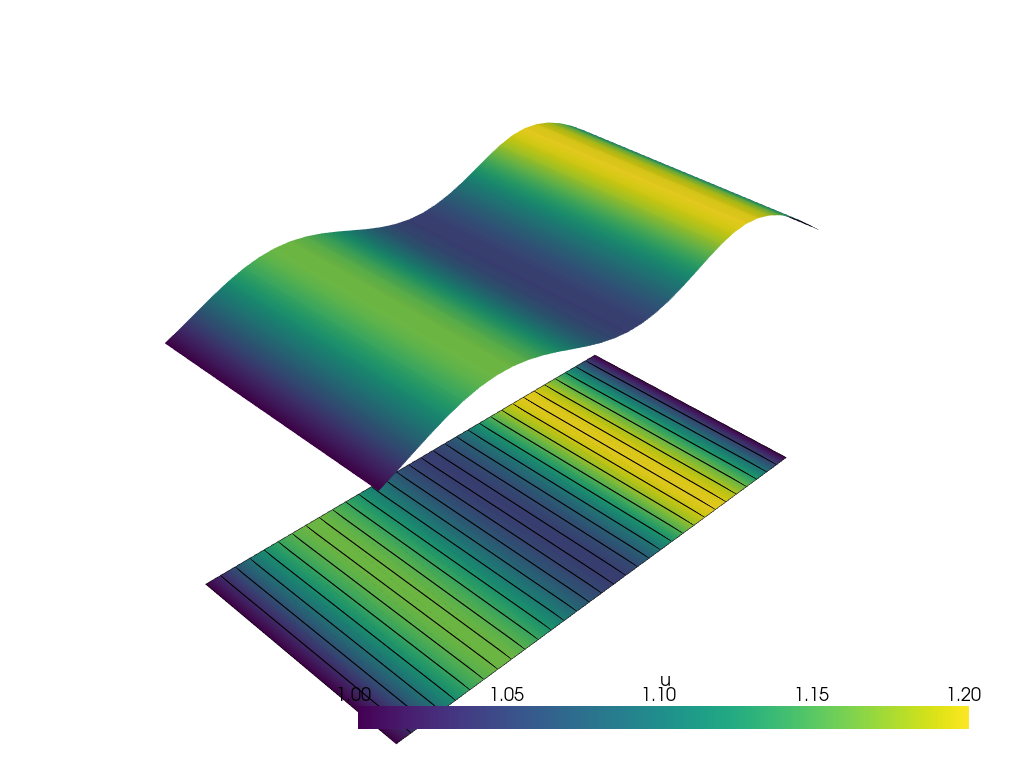

In [5]:
import pyvista

cells, types, x = plot.vtk_mesh(V)
grid = pyvista.UnstructuredGrid(cells, types, x)
grid.point_data["u"] = uh.x.array.real
grid.set_active_scalars("u")
plotter = pyvista.Plotter()
plotter.add_mesh(grid, show_edges=True)
warped = grid.warp_by_scalar()
plotter.add_mesh(warped)

plotter.show()